# Step 11: Price-level aggregation on QQQ

Companion to Lecture 2 of *Systematic Trading Notes*. Two separate operations are studied on real
QQQ data from 1999 onward: collapsing one bar into a single representative price (a compression),
and combining several bars into a smoothed estimate of the underlying price level (a causal
filter). Each method is defined, then computed by hand for one real date and checked against the
library value, then compared with the others on a common footing: equal memory, measured lag,
measured smoothness, and behaviour across three different market episodes.

Where a method already has a tested implementation in `trading_models` (Kaufman's Adaptive
Moving Average; the Kalman filter's trend state), it is imported rather than rewritten. Where none
exists, the computation is written here and marked as local.

References are listed at the end; they are given from memory and should be checked against the
originals before citation.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display
from plotly.subplots import make_subplots

from trading_models.data.ohlc import load_ohlc
from trading_models.momentum import kama
from trading_models.plotting import MUTED, SERIES, apply_theme, save_figure
from trading_models.trend_following.data.schema import InstrumentPanel
from trading_models.trend_following.signals.baselines.statistical import kalman_local_linear_trend

apply_theme()
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
RAW = ROOT / "data" / "raw"
FIG = ROOT / "lectures" / "02-ohlcv-and-moving-averages" / "figures"
TICKER = "QQQ"


## 1. Data

`trading_models.data.ohlc` caches adjusted open/high/low/close; it does not fetch volume, which
VWAP needs, so volume is fetched separately into its own cache file rather than changing that
loader for every other caller. The cache file names are specific to this notebook's date range:
`load_ohlc` checks whether a cache holds the requested *tickers*, not whether it covers the
requested *dates*, so reusing a shorter-history cache would silently truncate the sample.


In [2]:
def load_bars(ticker: str, start: str) -> pd.DataFrame:
    ohlc = load_ohlc([ticker], start=start, cache=RAW / f"nb11_{ticker.lower()}_ohlc_long.csv")
    bars = pd.DataFrame({f: ohlc[f][ticker] for f in ("open", "high", "low", "close")})
    vcache = RAW / f"nb11_{ticker.lower()}_volume_long.csv"
    if vcache.exists():
        bars["volume"] = pd.read_csv(vcache, index_col=0, parse_dates=True)[ticker]
    else:
        import yfinance as yf

        vol = yf.download([ticker], start=start, auto_adjust=True, actions=False, progress=False)["Volume"][ticker]
        vol.to_csv(vcache)
        bars["volume"] = vol
    return bars.dropna()


bars = load_bars(TICKER, "1993-01-01")
o, h, lw, c, v = (bars[k] for k in ("open", "high", "low", "close", "volume"))
print(f"{TICKER}: {len(bars)} daily bars, {bars.index[0].date()} to {bars.index[-1].date()}")


QQQ: 6940 daily bars, 1999-03-10 to 2026-10-09


## 2. From a bar to a single price

| Name | Formula | Emphasises |
|---|---|---|
| Close | $C$ | Where trading ended |
| Open | $O$ | Where trading began |
| Median Price (HL2) | $(H+L)/2$ | The range only |
| Typical Price (HLC3) | $(H+L+C)/3$ | The range, leaning toward the close |
| Weighted Close (HLCC4) | $(H+L+2C)/4$ | As above, close counted twice |
| OHLC4 | $(O+H+L+C)/4$ | All four prices equally |
| Body Midpoint | $(O+C)/2$ | The body only |

The constructions differ by an amount proportional to the bar's own range, so the differences are
largest on the widest-range bar in the sample, located below rather than chosen by eye.


In [3]:
prices = pd.DataFrame({
    "close": c, "open": o, "median_price": (h + lw) / 2, "typical_price": (h + lw + c) / 3,
    "weighted_close": (h + lw + 2 * c) / 4, "ohlc4": (o + h + lw + c) / 4, "body_mid": (o + c) / 2,
})
widest = ((h - lw) / c).idxmax()
print(f"Widest bar relative to its close: {widest.date()}, (H-L)/C = {((h - lw) / c).loc[widest]:.2%}")
print(f"  O={o[widest]:.2f}  H={h[widest]:.2f}  L={lw[widest]:.2f}  C={c[widest]:.2f}")
print(f"  Typical price by hand: ({h[widest]:.2f} + {lw[widest]:.2f} + {c[widest]:.2f}) / 3 = "
      f"{(h[widest] + lw[widest] + c[widest]) / 3:.2f}")
prices.loc[widest].round(2).to_frame("value")


Widest bar relative to its close: 2001-01-03, (H-L)/C = 20.97%
  O=43.93  H=54.92  L=43.90  C=52.56
  Typical price by hand: (54.92 + 43.90 + 52.56) / 3 = 50.46


,value
close,52.56
open,43.93
median_price,49.41
typical_price,50.46
weighted_close,50.99
ohlc4,48.83
body_mid,48.24


## 3. Five aggregation methods, each computed by hand once

All five are causal functions of past prices (Lecture 2, §3.2). For each, one real date is worked
through explicitly and the hand result is asserted equal to the library or vectorised value, so the
formula on the page is shown to be the one the code actually runs. The date is 24 August 2015, the
flash-crash open studied in Lecture 2's companion material.

$N = 20$ throughout this section.


In [4]:
N = 20
DAY = pd.Timestamp("2015-08-24")
i = c.index.get_loc(DAY)

sma = c.rolling(N).mean()
win = c.iloc[i - N + 1: i + 1]
print("SMA(20): mean of the last 20 closes")
print("  closes:", win.round(2).tolist())
print(f"  sum {win.sum():.2f} / 20 = {win.sum() / N:.4f};  library {sma.iloc[i]:.4f}")
assert np.isclose(win.sum() / N, sma.iloc[i])


SMA(20): mean of the last 20 closes
  closes: [102.45, 102.84, 103.32, 103.2, 102.88, 102.69, 103.48, 101.82, 101.69, 102.85, 101.54, 101.89, 101.72, 101.88, 102.72, 102.2, 101.53, 98.71, 94.4, 90.77]
  sum 2024.57 / 20 = 101.2287;  library 101.2287


**EMA.** $\mathrm{EMA}_t = \alpha p_t + (1-\alpha)\,\mathrm{EMA}_{t-1}$ with $\alpha = 2/(N+1)$.
`pandas`' `ewm` defaults to `adjust=True`, which re-normalises the weights during the warm-up
period and therefore does not follow this recursion exactly for the first few dozen bars;
`adjust=False` is the recursion as written. The two converge once the warm-up has passed, but the
difference matters for any backtest that starts near the beginning of the data.


In [5]:
alpha = 2 / (N + 1)
ema = c.ewm(span=N, adjust=False).mean()
hand = alpha * c.iloc[i] + (1 - alpha) * ema.iloc[i - 1]
print(f"EMA(20): alpha = 2/21 = {alpha:.4f}")
print(f"  {alpha:.4f} x {c.iloc[i]:.2f} + {1 - alpha:.4f} x {ema.iloc[i - 1]:.4f} = {hand:.4f};  library {ema.iloc[i]:.4f}")
assert np.isclose(hand, ema.iloc[i])
gap = (c.ewm(span=N).mean() - ema).abs() / c
print(f"  adjust=True vs adjust=False, largest gap in the first 50 bars: {gap.iloc[:50].max():.3%}; after bar 200: {gap.iloc[200:].max():.2e}")


EMA(20): alpha = 2/21 = 0.0952
  0.0952 x 90.77 + 0.9048 x 101.1359 = 100.1484;  library 100.1484
  adjust=True vs adjust=False, largest gap in the first 50 bars: 0.492%; after bar 200: 6.12e-10


**VWAP.** $\mathrm{VWAP}_t = \sum_k p_{t-k} v_{t-k} / \sum_k v_{t-k}$ over the last $N$ bars,
using Typical Price as $p$ (the usual convention). Not in `trading_models`; computed locally.


In [6]:
def vwap(price: pd.Series, volume: pd.Series, window: int) -> pd.Series:
    return (price * volume).rolling(window).sum() / volume.rolling(window).sum()


tp = prices["typical_price"]
vwap20 = vwap(tp, v, N)
pv = (tp * v).iloc[i - N + 1: i + 1]
vw = v.iloc[i - N + 1: i + 1]
print(f"VWAP(20): sum(p*v) = {pv.sum():,.0f};  sum(v) = {vw.sum():,.0f};  ratio = {pv.sum() / vw.sum():.4f}")
print(f"  share of the window's volume traded on {DAY.date()} itself: {v.iloc[i] / vw.sum():.1%} (one of 20 bars)")
assert np.isclose(pv.sum() / vw.sum(), vwap20.iloc[i])


VWAP(20): sum(p*v) = 76,773,001,042;  sum(v) = 780,053,400;  ratio = 98.4202
  share of the window's volume traded on 2015-08-24 itself: 19.3% (one of 20 bars)


**KAMA** (Kaufman). Efficiency ratio
$\mathrm{ER}_t = |p_t - p_{t-n}| \,/\, \sum_{k=0}^{n-1}|p_{t-k}-p_{t-k-1}|$, smoothing constant
$\mathrm{sc}_t = (\mathrm{ER}_t(\alpha_f-\alpha_s)+\alpha_s)^2$ with $\alpha_f=2/3$, $\alpha_s=2/31$, and
$\mathrm{KAMA}_t = \mathrm{KAMA}_{t-1} + \mathrm{sc}_t(p_t-\mathrm{KAMA}_{t-1})$. Imported from
`trading_models.momentum.kama` with Kaufman's own $n=10$; the hand step below reproduces one bar.


In [7]:
kama10 = kama(c.to_frame(TICKER), er_window=10, fast=2, slow=30)[TICKER]
net = abs(c.iloc[i] - c.iloc[i - 10])
path = c.diff().abs().iloc[i - 9: i + 1].sum()
er = net / path
af, aslow = 2 / 3, 2 / 31
sc = (er * (af - aslow) + aslow) ** 2
hand = kama10.iloc[i - 1] + sc * (c.iloc[i] - kama10.iloc[i - 1])
print(f"KAMA: net move {net:.2f} / path {path:.2f} = ER {er:.3f};  sc = {sc:.4f}")
print(f"  {kama10.iloc[i - 1]:.4f} + {sc:.4f} x ({c.iloc[i]:.2f} - {kama10.iloc[i - 1]:.4f}) = {hand:.4f};  library {kama10.iloc[i]:.4f}")
assert np.isclose(hand, kama10.iloc[i])


KAMA: net move 12.09 / path 14.80 = ER 0.817;  sc = 0.3095
  100.8618 + 0.3095 x (90.77 - 100.8618) = 97.7373;  library 97.7373


**Kalman filter** (local linear trend). State: level $\ell_t$ and trend $\tau_t$ of log price,
$\ell_t = \ell_{t-1}+\tau_{t-1}+\eta^\ell_t$, $\tau_t=\tau_{t-1}+\eta^\tau_t$, observed as
$\log p_t = \ell_t+\varepsilon_t$. Each bar: predict ($\hat\ell=\ell_{t-1}+\tau_{t-1}$), then correct by the
gain times the innovation. `trading_models`' `kalman_local_linear_trend` returns only the trend
state; the local function below returns both states and the gain, and is first checked against the
package by asserting the trend states agree on every bar.


In [8]:
def kalman_llt(y: np.ndarray, level_var=1e-4, trend_var=1e-6, obs_var=1e-3):
    n = len(y)
    lvl, trd, gain = np.empty(n), np.empty(n), np.empty(n)
    level, trend = y[0], 0.0
    c00, c01, c10, c11 = 1.0, 0.0, 0.0, 1.0
    for t in range(n):
        level = level + trend
        p00, p01, p10, p11 = c00 + c10 + c01 + c11, c01 + c11, c10 + c11, c11
        c00, c01, c10, c11 = p00 + level_var, p01, p10, p11 + trend_var
        s = c00 + obs_var
        g0, g1 = c00 / s, c10 / s
        innov = y[t] - level
        level, trend = level + g0 * innov, trend + g1 * innov
        c00, c01, c10, c11 = (1 - g0) * c00, (1 - g0) * c01, c10 - g1 * c00, c11 - g1 * c01
        lvl[t], trd[t], gain[t] = level, trend, g0
    return lvl, trd, gain


logc = np.log(c.to_numpy())
lvl, trd, g = kalman_llt(logc)
pkg_trend = kalman_local_linear_trend(InstrumentPanel(close=c.to_frame(TICKER)))[TICKER].to_numpy()
assert np.allclose(trd, pkg_trend), "local recursion does not match trading_models"
print("Trend state matches trading_models on all", len(trd), "bars.")

pred = lvl[i - 1] + trd[i - 1]
innov = logc[i] - pred
print(f"Kalman, {DAY.date()} (log space): predicted level {pred:.5f}, observed log price {logc[i]:.5f}")
print(f"  innovation {innov:+.5f} x gain {g[i]:.4f} = correction {g[i] * innov:+.5f} -> level {pred + g[i] * innov:.5f}")
print(f"  in price terms: exp(level) = {np.exp(lvl[i]):.2f} against a close of {c.iloc[i]:.2f}")
assert np.isclose(pred + g[i] * innov, lvl[i])


Trend state matches trading_models on all

 6940 bars.
Kalman, 2015-08-24 (log space): predicted level 4.58826, observed log price 4.50830
  innovation -0.07995 x gain 0.3316 = correction -0.02651 -> level 4.56174
  in price terms: exp(level) = 95.75 against a close of 90.77


## 4. Matching memory before comparing

A comparison of "SMA(20) against a Kalman filter" is only meaningful if the two carry the same
amount of memory. For a linear smoother $\hat p_t=\sum_{k\ge0} w_k p_{t-k}$ with $\sum w_k=1$, two
standard summaries of memory are:

- **Average age of the data** (centre of mass), $\sum_k k\,w_k$. On a price rising along a straight
  line, this is exactly how many bars the smoother trails behind.
- **Variance reduction factor**, $\sum_k w_k^2$. If prices were independent noise around a constant,
  the smoother's variance would be this fraction of the noise variance.

Brown (1963) chose the exponential-smoothing convention $\alpha=2/(N+1)$ precisely so that an EMA
and an $N$-period SMA have the same average age, $(N-1)/2$; it follows that they also share the
same variance reduction factor, $1/N$. Wilder's smoothing ($\alpha=1/n$, used in ATR and ADX) is an
EMA with span $2n-1$: "ATR(14)" carries the memory of a 27-bar average, not a 14-bar one.

The Kalman local-linear-trend filter is the exception. In steady state it is equivalent to Holt's
linear exponential smoothing (Harvey, 1989), and its weights turn negative for old observations so
that a linear trend is tracked with **zero** average lag, whatever the noise settings. Average age
cannot calibrate it; the variance reduction factor can. Below its observation-noise variance is
solved for so that its variance reduction matches $1/20$.


In [9]:
def kalman_weights(obs_var, n=600, warm=3000):
    # impulse response of the steady-state filter: run to steady state on zeros, then feed one unit impulse
    y = np.zeros(warm + n)
    base, _, _ = kalman_llt(y, obs_var=obs_var)
    y[warm] = 1.0
    resp, _, _ = kalman_llt(y, obs_var=obs_var)
    return (resp - base)[warm:]


def memory(w):
    k = np.arange(len(w))
    return (k * w).sum() / w.sum(), (w ** 2).sum() / w.sum() ** 2


lo, hi = 1e-4, 10.0
for _ in range(60):
    mid = np.sqrt(lo * hi)
    lo, hi = (mid, hi) if 1 / memory(kalman_weights(mid))[1] < N else (lo, mid)
OBS_VAR_N = mid

ages = np.arange(120)
w_sma = np.where(ages < N, 1 / N, 0.0)
w_ema = alpha * (1 - alpha) ** ages
w_wild = (1 / 14) * (1 - 1 / 14) ** ages
w_kal_default = kalman_weights(1e-3)[:120]
w_kal_n = kalman_weights(OBS_VAR_N)[:120]
table = pd.DataFrame({
    "SMA(20)": memory(w_sma), "EMA(span 20)": memory(alpha * (1 - alpha) ** np.arange(3000)),
    "Wilder(14)": memory((1 / 14) * (1 - 1 / 14) ** np.arange(3000)),
    "Kalman, default obs_var=1e-3": memory(kalman_weights(1e-3)),
    f"Kalman, obs_var={OBS_VAR_N:.3f}": memory(kalman_weights(OBS_VAR_N)),
}, index=["average age (bars)", "variance reduction"]).T
table["noise-equivalent N"] = 1 / table["variance reduction"]
table.round(3)


,average age (bars),variance reduction,noise-equivalent N
SMA(20),9.5,0.050,20.000
EMA(span 20),9.5,0.050,20.000
Wilder(14),13.0,0.037,27.000
"Kalman, default obs_var=1e-3",-0.0,0.224,4.465
"Kalman, obs_var=0.200",-0.0,0.050,20.000


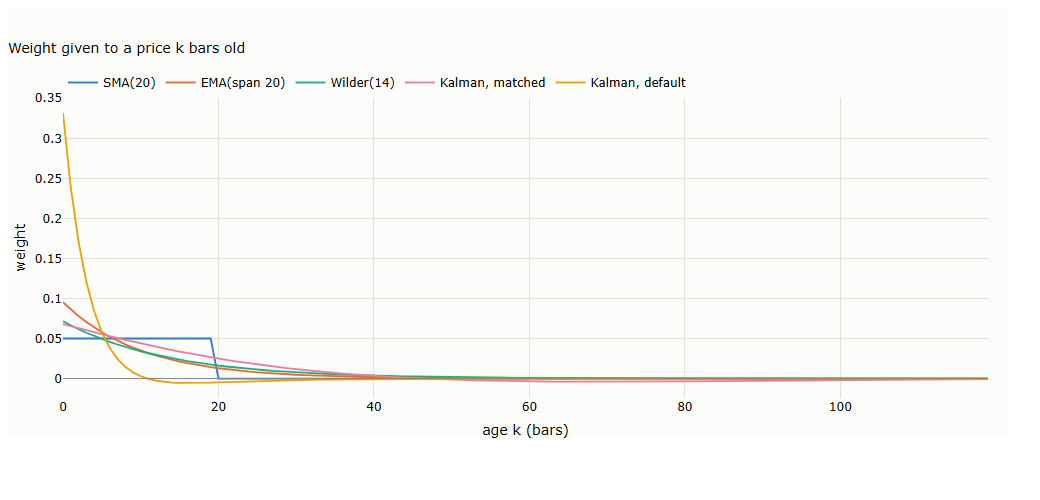

In [10]:
fig = go.Figure()
for name, w, col in [("SMA(20)", w_sma, SERIES[0]), ("EMA(span 20)", w_ema, SERIES[1]),
                     ("Wilder(14)", w_wild, SERIES[2]), ("Kalman, matched", w_kal_n, SERIES[3]),
                     ("Kalman, default", w_kal_default, SERIES[4])]:
    fig.add_scatter(x=ages, y=w, name=name, mode="lines", line=dict(width=1.8, color=col))
fig.add_hline(y=0, line=dict(color=MUTED, width=1))
fig.update_layout(title="Weight given to a price k bars old", xaxis_title="age k (bars)",
                  yaxis_title="weight", height=430, width=1000, margin=dict(t=90))
save_figure(fig, "11_01_memory_weights", FIG)
fig


## 5. Lag, measured on controlled inputs

Lag is easiest to measure where the right answer is known: a price that jumps once (a step) and a
price that starts rising at a constant rate (a ramp). Two measurements per method: bars needed to
cover half of a unit step, and the steady distance behind a ramp, in bars. The step response also
reveals **overshoot**, which the Kalman filter's trend state produces after a jump: it reads part of
the jump as the start of a trend and extrapolates it. KAMA's near-instant response here is
flattered by the inputs being free of noise, which drives its efficiency ratio to 1.


In [11]:
n_syn = 220
tt = np.arange(n_syn)
step = np.where(tt < 100, 100.0, 101.0)
ramp = np.where(tt < 100, 100.0, 100.0 + 0.01 * (tt - 100))


def smooth_all(x: np.ndarray) -> pd.DataFrame:
    s = pd.Series(x)
    lvl_k, _, _ = kalman_llt(np.log(x), obs_var=OBS_VAR_N)
    return pd.DataFrame({
        "SMA(20)": s.rolling(N).mean(), "EMA(20)": s.ewm(span=N, adjust=False).mean(),
        "KAMA(10)": kama(s.to_frame("x"), er_window=10)["x"], "Kalman (matched)": np.exp(lvl_k),
    })


st, rp = smooth_all(step), smooth_all(ramp)
rows = {}
for col in st:
    after = st[col].iloc[100:] - 100
    rows[col] = {"bars to 50% of step": int((after >= 0.5).to_numpy().argmax()),
                 "overshoot": f"{max(0.0, after.max() - 1):.1%}",
                 "lag behind ramp (bars)": round((ramp[200] - rp[col].iloc[200]) / 0.01, 1)}
pd.DataFrame(rows).T


,bars to 50% of step,overshoot,lag behind ramp (bars)
SMA(20),9,0.0%,9.5
EMA(20),6,0.0%,9.5
KAMA(10),1,0.0%,1.3
Kalman (matched),8,19.0%,-0.1


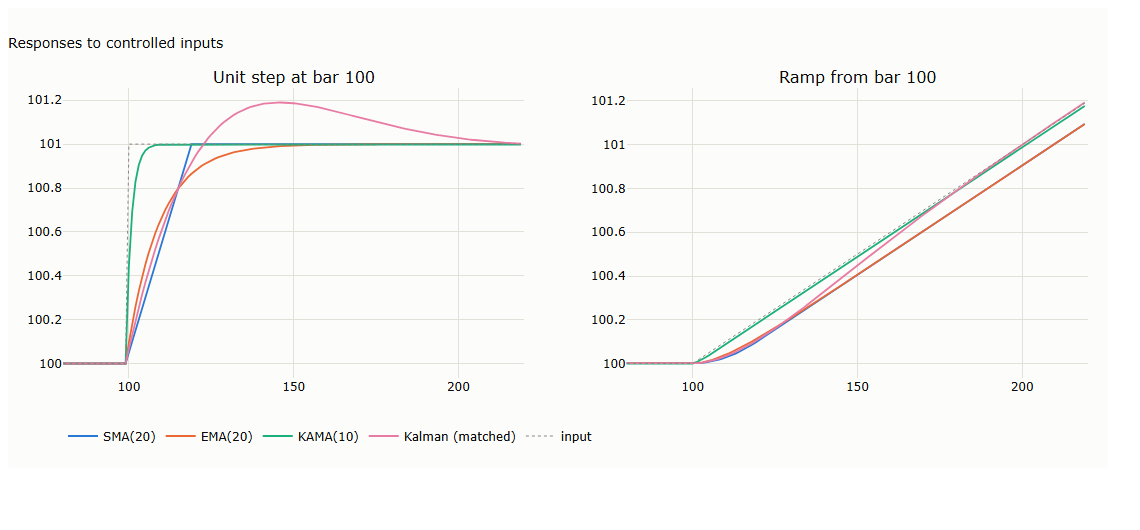

In [12]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("Unit step at bar 100", "Ramp from bar 100"))
for j, col in enumerate(st):
    fig.add_scatter(x=tt, y=st[col], name=col, mode="lines", line=dict(width=1.8, color=SERIES[j]), row=1, col=1)
    fig.add_scatter(x=tt, y=rp[col], name=col, mode="lines", showlegend=False, line=dict(width=1.8, color=SERIES[j]), row=1, col=2)
fig.add_scatter(x=tt, y=step, name="input", mode="lines", line=dict(width=1, color=MUTED, dash="dot"), row=1, col=1)
fig.add_scatter(x=tt, y=ramp, name="input", showlegend=False, mode="lines", line=dict(width=1, color=MUTED, dash="dot"), row=1, col=2)
fig.update_xaxes(range=[80, 220])
fig.update_layout(title="Responses to controlled inputs", height=460, width=1100, margin=dict(t=80, b=90),
                  legend=dict(orientation="h", y=-0.15, x=0))
save_figure(fig, "11_02_step_ramp", FIG)
fig


## 6. Smoothness and tracking on real data, three episodes

Two scale-free measures, computed on log prices so that a 1999 bar and a 2026 bar count equally:

- **Roughness**: standard deviation of the smoother's daily log change divided by that of price
  (1 = no smoothing, 0 = a flat line).
- **Tracking gap**: root-mean-square distance between smoother and price, in percent.

The pairs that section 4 matched on memory should show similar roughness; if one of them then
also tracks price more closely, it is genuinely better at this job rather than merely smoothing
less. The Kalman filter with the package's default noise setting is included to show what an
unmatched comparison looks like.


In [13]:
lvl_def, _, _ = kalman_llt(np.log(c.to_numpy()), obs_var=1e-3)
lvl_n, _, _ = kalman_llt(np.log(c.to_numpy()), obs_var=OBS_VAR_N)
smoothers = pd.DataFrame({
    "SMA(20)": sma, "EMA(20)": ema, "VWAP(20)": vwap20, "KAMA(10)": kama10,
    "Kalman, matched": pd.Series(np.exp(lvl_n), index=c.index),
    "Kalman, default": pd.Series(np.exp(lvl_def), index=c.index),
})
EPISODES = {"Full sample": ("2000-01-01", "2026-12-31"), "Aug 2015": ("2015-07-01", "2015-10-31"),
            "Covid 2020": ("2020-01-15", "2020-05-31"), "2022 drawdown": ("2021-11-01", "2022-12-31")}


def scores(lo, hi):
    lp = np.log(c.loc[lo:hi])
    out = {}
    for col in smoothers:
        ls = np.log(smoothers[col].loc[lo:hi])
        out[col] = (ls.diff().std() / lp.diff().std(), 100 * np.sqrt(((lp - ls) ** 2).mean()))
    return out


res = {ep: scores(*span) for ep, span in EPISODES.items()}
rough = pd.DataFrame({ep: {k: v[0] for k, v in r.items()} for ep, r in res.items()}).round(3)
track = pd.DataFrame({ep: {k: v[1] for k, v in r.items()} for ep, r in res.items()}).round(2)
print("Roughness (1 = raw price):")
display(rough)
print("Tracking gap, RMS % from price:")
display(track)


Roughness (1 = raw price):


,Full sample,Aug 2015,Covid 2020,2022 drawdown
SMA(20),0.198,0.175,0.198,0.189
EMA(20),0.198,0.194,0.180,0.188
VWAP(20),0.206,0.286,0.195,0.192
KAMA(10),0.279,0.396,0.206,0.242
"Kalman, matched",0.199,0.171,0.184,0.182
"Kalman, default",0.438,0.496,0.383,0.440


Tracking gap, RMS % from price:


,Full sample,Aug 2015,Covid 2020,2022 drawdown
SMA(20),3.74,3.16,6.75,4.27
EMA(20),3.25,2.67,5.58,3.66
VWAP(20),3.70,2.95,6.43,4.15
KAMA(10),2.98,2.20,5.59,3.60
"Kalman, matched",3.84,3.22,7.45,4.47
"Kalman, default",1.42,1.38,2.28,1.66


**Reading the two tables together.**

- SMA(20), EMA(20) and the matched Kalman filter have nearly identical roughness (about 0.18–0.20
  in every period), as the memory matching in section 4 intends. Among these three the EMA tracks
  price most closely in all four periods, so its advantage over the SMA is real, not a by-product
  of smoothing less.
- The matched Kalman filter tracks price *least* closely of the three despite having no lag on a
  straight trend. Real prices contain jumps, and the overshoot measured in section 5 costs more
  than the zero ramp lag saves.
- KAMA and the Kalman filter at its default setting track price more closely than everything else,
  but they are also much rougher (about 0.28 and 0.44 over the full sample). They follow price more
  closely mainly because they smooth less; that is not a like-for-like advantage.
- VWAP's roughness rises sharply in August 2015 (0.29 against about 0.18 for SMA): a single
  heavy-volume bar takes a large share of the weights, as the hand calculation in section 3 showed
  (19% of the window's volume on one of twenty days).


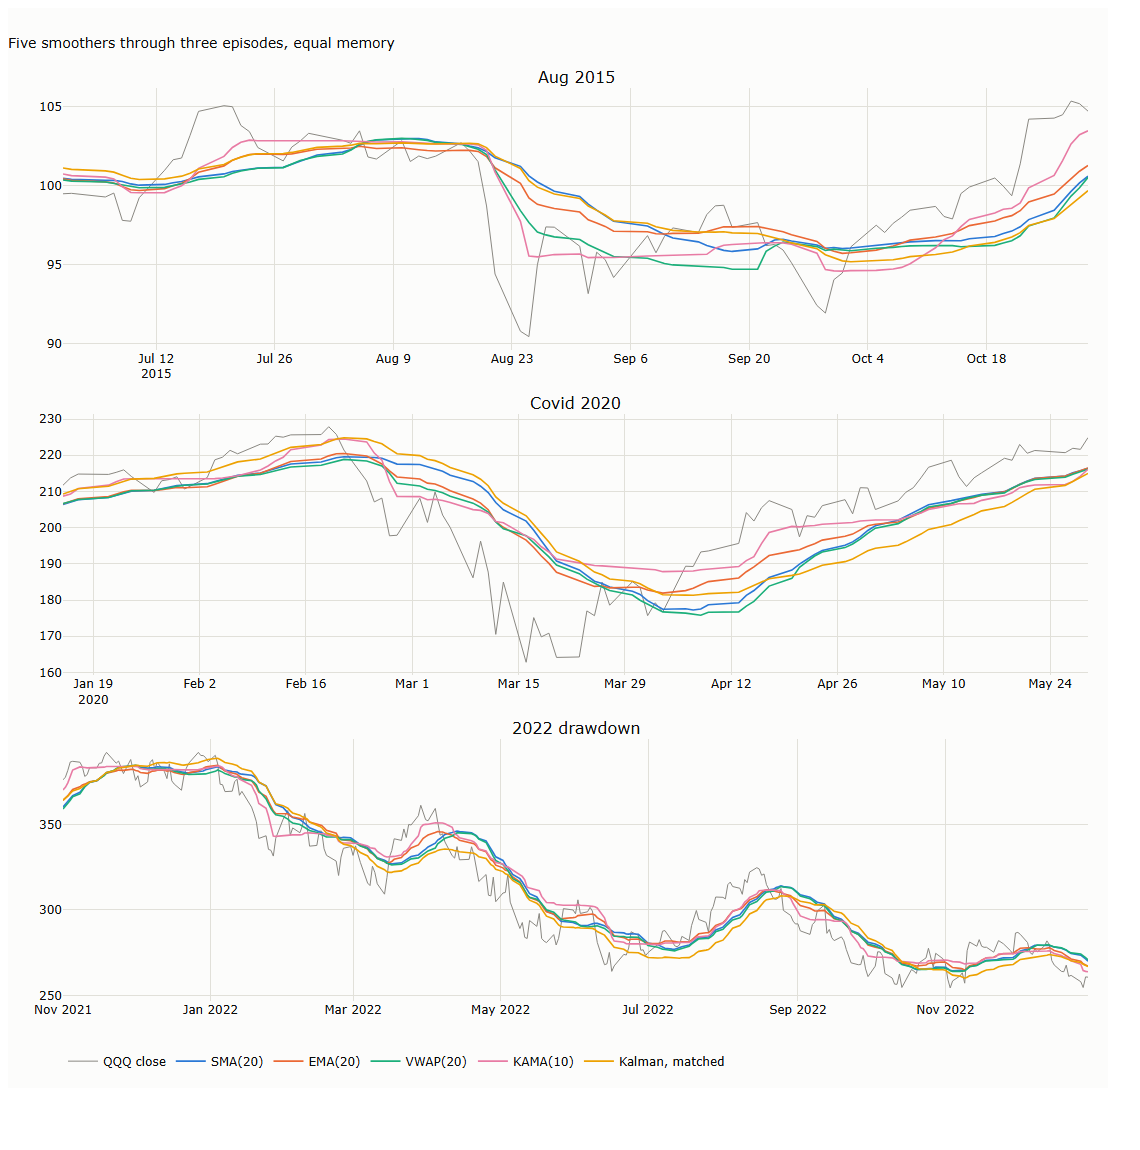

In [14]:
fig = make_subplots(rows=3, cols=1, vertical_spacing=0.07,
                    subplot_titles=[f"{k}" for k in list(EPISODES)[1:]])
show = ["SMA(20)", "EMA(20)", "VWAP(20)", "KAMA(10)", "Kalman, matched"]
for r_, (_ep, (lo, hi)) in enumerate(list(EPISODES.items())[1:], start=1):
    p = c.loc[lo:hi]
    fig.add_scatter(x=p.index, y=p, name="QQQ close", mode="lines", line=dict(width=1, color=MUTED),
                    showlegend=(r_ == 1), row=r_, col=1)
    for j, col in enumerate(show):
        s = smoothers[col].loc[lo:hi]
        fig.add_scatter(x=s.index, y=s, name=col, mode="lines", line=dict(width=1.6, color=SERIES[j]),
                        showlegend=(r_ == 1), row=r_, col=1)
fig.update_layout(title="Five smoothers through three episodes, equal memory", height=1080, width=1100,
                  margin=dict(t=80, b=80), legend=dict(orientation="h", y=-0.05, x=0))
save_figure(fig, "11_03_episodes", FIG)
fig


## 7. Sensitivity to the window length

The choice of $N$ usually matters more than the choice of method. Below, each method at
$N = 10, 20, 50$ through the 2020 episode, the Kalman filter re-calibrated to each $N$ by the
same variance-reduction rule as in section 4. There is no correct $N$ in general: shorter windows
follow the crash and the rebound sooner and are noisier in calm periods; longer windows are the
reverse. Standard defaults (20, 50, 200) are conventions, not results.


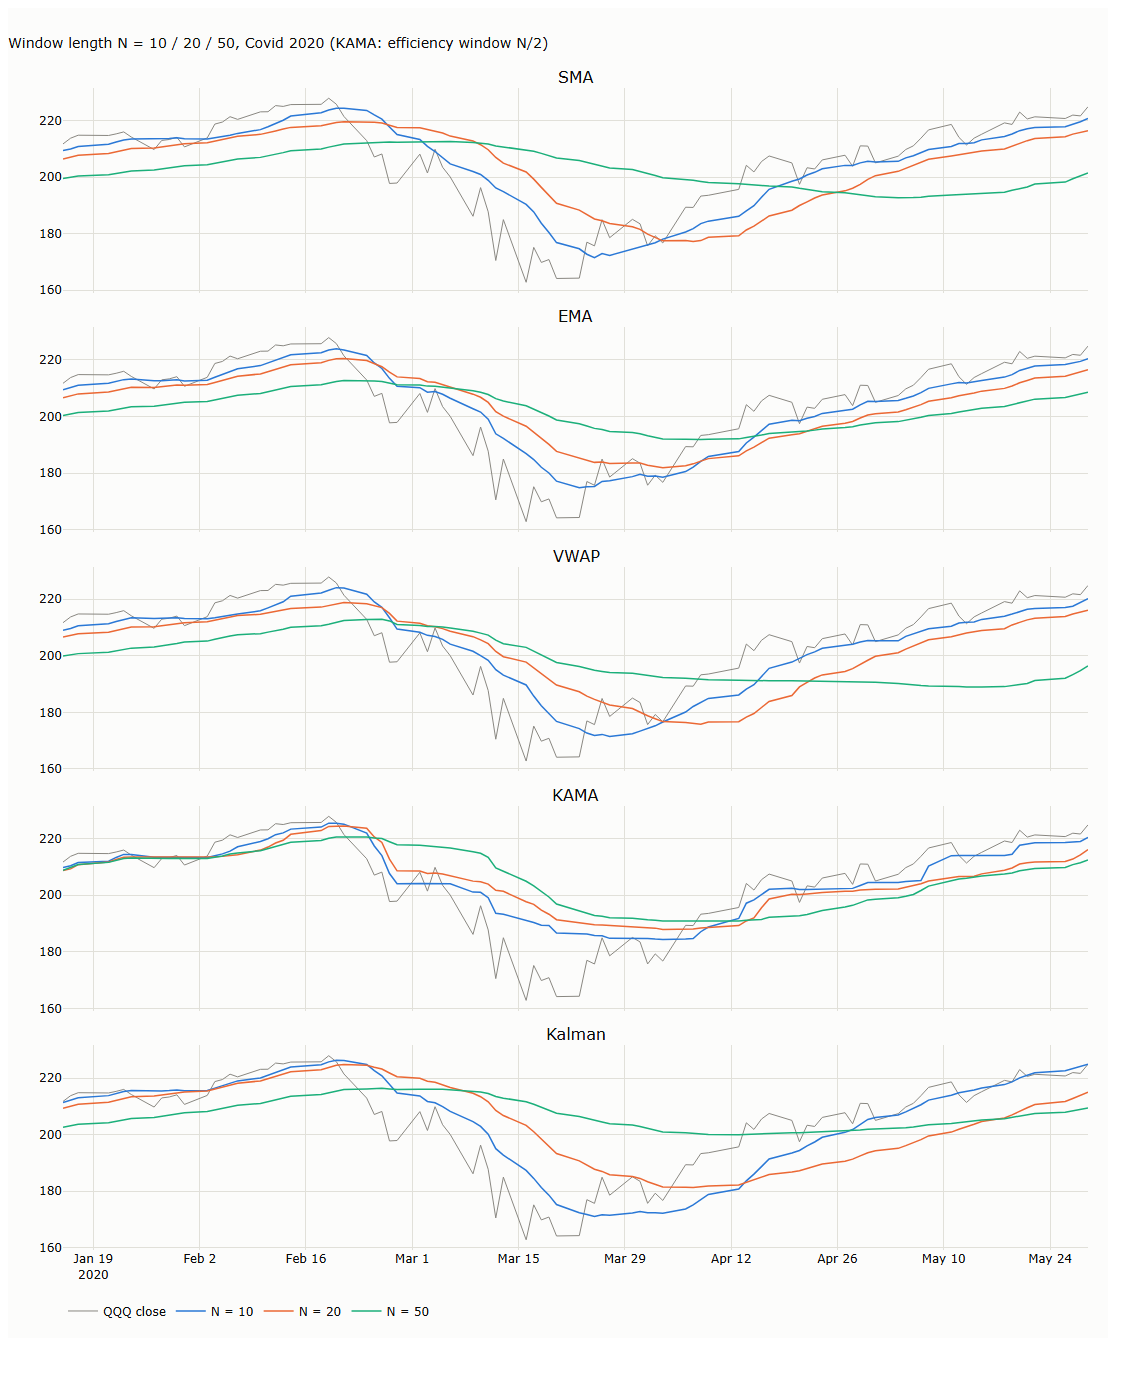

In [15]:
def obs_var_for(n_target):
    lo_, hi_ = 1e-5, 100.0
    for _ in range(60):
        m = np.sqrt(lo_ * hi_)
        lo_, hi_ = (m, hi_) if 1 / memory(kalman_weights(m))[1] < n_target else (lo_, m)
    return m


lo, hi = EPISODES["Covid 2020"]
methods = ["SMA", "EMA", "VWAP", "KAMA", "Kalman"]
fig = make_subplots(rows=len(methods), cols=1, shared_xaxes=True, vertical_spacing=0.03, subplot_titles=methods)
p = c.loc[lo:hi]
for r_, m in enumerate(methods, start=1):
    fig.add_scatter(x=p.index, y=p, mode="lines", line=dict(width=1, color=MUTED), name="QQQ close",
                    showlegend=(r_ == 1), row=r_, col=1)
    for j, n_ in enumerate([10, 20, 50]):
        if m == "SMA":
            s = c.rolling(n_).mean()
        elif m == "EMA":
            s = c.ewm(span=n_, adjust=False).mean()
        elif m == "VWAP":
            s = vwap(tp, v, n_)
        elif m == "KAMA":
            s = kama(c.to_frame(TICKER), er_window=n_ // 2)[TICKER]
        else:
            s = pd.Series(np.exp(kalman_llt(np.log(c.to_numpy()), obs_var=obs_var_for(n_))[0]), index=c.index)
        fig.add_scatter(x=p.index, y=s.loc[lo:hi], mode="lines", line=dict(width=1.5, color=SERIES[j]),
                        name=f"N = {n_}", showlegend=(r_ == 1), row=r_, col=1)
fig.update_layout(title="Window length N = 10 / 20 / 50, Covid 2020 (KAMA: efficiency window N/2)",
                  height=1330, width=1100, margin=dict(t=80, b=80), legend=dict(orientation="h", y=-0.04, x=0))
save_figure(fig, "11_04_sensitivity", FIG)
fig


## 8. Practical notes

| Method | Inputs | Warm-up | Value known | Common mistake |
|---|---|---|---|---|
| SMA | Close | $N$ bars | After the close of bar $t$ | Treating SMA(20) and ATR(20) as the same length (ATR(20) has the memory of a 39-bar average) |
| EMA | Close | Formally none; in practice several $N$ | After the close | Mixing `adjust=True` and the textbook recursion in a backtest that starts early |
| VWAP | Price and volume | $N$ bars | After the close | Using split-unadjusted volume with split-adjusted prices |
| KAMA | Close | Efficiency window + several bars | After the close | Judging its speed on clean examples; on noisy data it is far slower |
| Kalman (local linear trend) | Close (log) | Until the gain settles | After the close | Comparing it at default noise settings against a 20-bar average, which is not a like-for-like comparison |

None of these values is known before the bar closes. A signal computed from bar $t$ can be traded
at the close of bar $t$ at the earliest, and only if the computation is done in the final moments
of the session; otherwise at the next bar.

## 9. Summary

- Every formula above was checked against the code that implements it on a real date, including
  the Kalman filter's trend state against the `trading_models` implementation on every bar.
- Comparisons are only fair at equal memory. SMA and EMA are matched by Brown's convention; the
  Kalman filter has zero lag on trends by construction and must be matched on variance reduction
  instead. Its default noise setting in `trading_models` corresponds to roughly a 4–5 bar average.
- Section 5 measures the trade-offs directly: EMA covers half a step faster than SMA at the same
  average lag; the Kalman filter has no lag on a trend but overshoots after a jump.
- Section 6 shows whether those properties survive real data, across three episodes, at equal
  smoothness. Section 7 shows that the window length moves the result more than the method does.

## References

- Brown, R.G. (1963). *Smoothing, Forecasting and Prediction of Discrete Time Series.* Prentice-Hall.
- Holt, C.C. (1957, reprinted 2004). Forecasting seasonals and trends by exponentially weighted moving averages. *International Journal of Forecasting.*
- Harvey, A.C. (1989). *Forecasting, Structural Time Series Models and the Kalman Filter.* Cambridge University Press.
- Kaufman, P. (2013). *Trading Systems and Methods* (5th ed.). Wiley.
- Wilder, J.W. (1978). *New Concepts in Technical Trading Systems.* Trend Research.
